# House Price Prediction

### Import the necessary libraries and load the dataset.

In [255]:
import re
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [256]:
train_df = pd.read_csv('Datasets/train_(2)_(1)_(1).csv')
test_df = pd.read_csv('Datasets/test_(2)_(1)_(1).csv')
avg_rent = pd.read_csv('Datasets/avg_rent_(1)_(1)_(1).csv')

In [257]:
train_df.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [258]:
avg_rent.head()

,location,avg_2bhk_rent
0,Krishnarajapura,11954
1,Sarjapur,45000
2,Whitefield Hope Farm Junction,26370
3,Devanahalli,17302
4,Whitefield,14981


In [259]:
test_df.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony
0,0,Super built-up Area,Ready To Move,Chamrajpet,2 BHK,NaN,650,1.0,1.0
1,1,Super built-up Area,Ready To Move,7th Phase JP Nagar,3 BHK,SrncyRe,1370,2.0,1.0
2,2,Super built-up Area,Ready To Move,Whitefield,3 BHK,AjhalNa,1725,3.0,2.0
3,3,Built-up Area,Ready To Move,Jalahalli,2 BHK,NaN,1000,2.0,0.0
4,4,Plot Area,Ready To Move,TC Palaya,1 Bedroom,NaN,1350,1.0,0.0


In [260]:
train_df.shape

(10656, 10)

In [261]:
avg_rent.shape

(157, 2)

In [262]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10656 entries, 0 to 10655
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            10656 non-null  int64  
 1   area_type     10656 non-null  object 
 2   availability  10656 non-null  object 
 3   location      10655 non-null  object 
 4   size          10642 non-null  object 
 5   society       6228 non-null   object 
 6   total_sqft    10656 non-null  object 
 7   bath          10591 non-null  float64
 8   balcony       10152 non-null  float64
 9   price         10656 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 832.6+ KB


##### We can observe that more features are object and some of the features have missing values.

In [263]:
train_df.describe()

,ID,bath,balcony,price
count,10656.000000,10591.000000,10152.000000,10656.000000
mean,5327.500000,2.690586,1.581757,112.214256
std,3076.266568,1.352403,0.821357,142.231967
min,0.000000,1.000000,0.000000,8.000000
25%,2663.750000,2.000000,1.000000,50.000000
50%,5327.500000,2.000000,2.000000,72.000000
75%,7991.250000,3.000000,2.000000,120.000000
max,10655.000000,40.000000,3.000000,2700.000000


In [264]:
train_df.isna().sum()

ID                 0
area_type          0
availability       0
location           1
size              14
society         4428
total_sqft         0
bath              65
balcony          504
price              0
dtype: int64

##### Will take a copy of the dataframe to avoid any changes to the original dataframe.

In [265]:
train_df_copy = train_df.copy()

### Data Cleaning and Preprocessing

In [266]:
train_df_copy['society'].unique()

array(['Coomee ', 'Theanmp', nan, ..., 'ArariGo', 'Vicony ', 'Srhemay'],
      dtype=object)

In [267]:
train_df_copy['society'].nunique()

2364

##### Will drop the 'ID' column as it does not contribute to the prediction. 

##### Also 'society' column has a lot of unique values which may not contribute to the prediction. Hence dropping that too.

In [268]:
train_df_copy['area_type'].value_counts()

area_type
Super built-up  Area    7009
Built-up  Area          1927
Plot  Area              1651
Carpet  Area              69
Name: count, dtype: int64

In [269]:
train_df_copy['availability'].unique()

array(['19-Dec', 'Ready To Move', '18-May', '18-Feb', '18-Nov', '20-Dec',
       '17-Oct', '21-Dec', '19-Sep', '20-Sep', '18-Mar', '20-Feb',
       '18-Apr', '20-Aug', '18-Oct', '19-Mar', '17-Sep', '18-Dec',
       '17-Aug', '19-Apr', '18-Jun', '22-Dec', '22-Jan', '18-Aug',
       '19-Jan', '17-Jul', '18-Jul', '21-Jun', '20-May', '19-Aug',
       '18-Sep', '17-May', '17-Jun', '21-May', '18-Jan', '20-Mar',
       '17-Dec', '16-Mar', '19-Jun', '22-Jun', '19-Jul', '21-Feb',
       'Immediate Possession', '19-May', '17-Nov', '20-Oct', '20-Jun',
       '19-Feb', '21-Oct', '21-Jan', '17-Mar', '17-Apr', '22-May',
       '19-Oct', '21-Jul', '21-Nov', '21-Mar', '16-Dec', '22-Mar',
       '20-Jan', '21-Sep', '21-Aug', '14-Nov', '19-Nov', '15-Nov',
       '16-Jul', '15-Jun', '17-Feb', '20-Nov', '20-Jul', '16-Sep',
       '15-Oct', '15-Dec', '16-Oct', '22-Nov', '15-Aug', '17-Jan',
       '16-Nov', '20-Apr'], dtype=object)

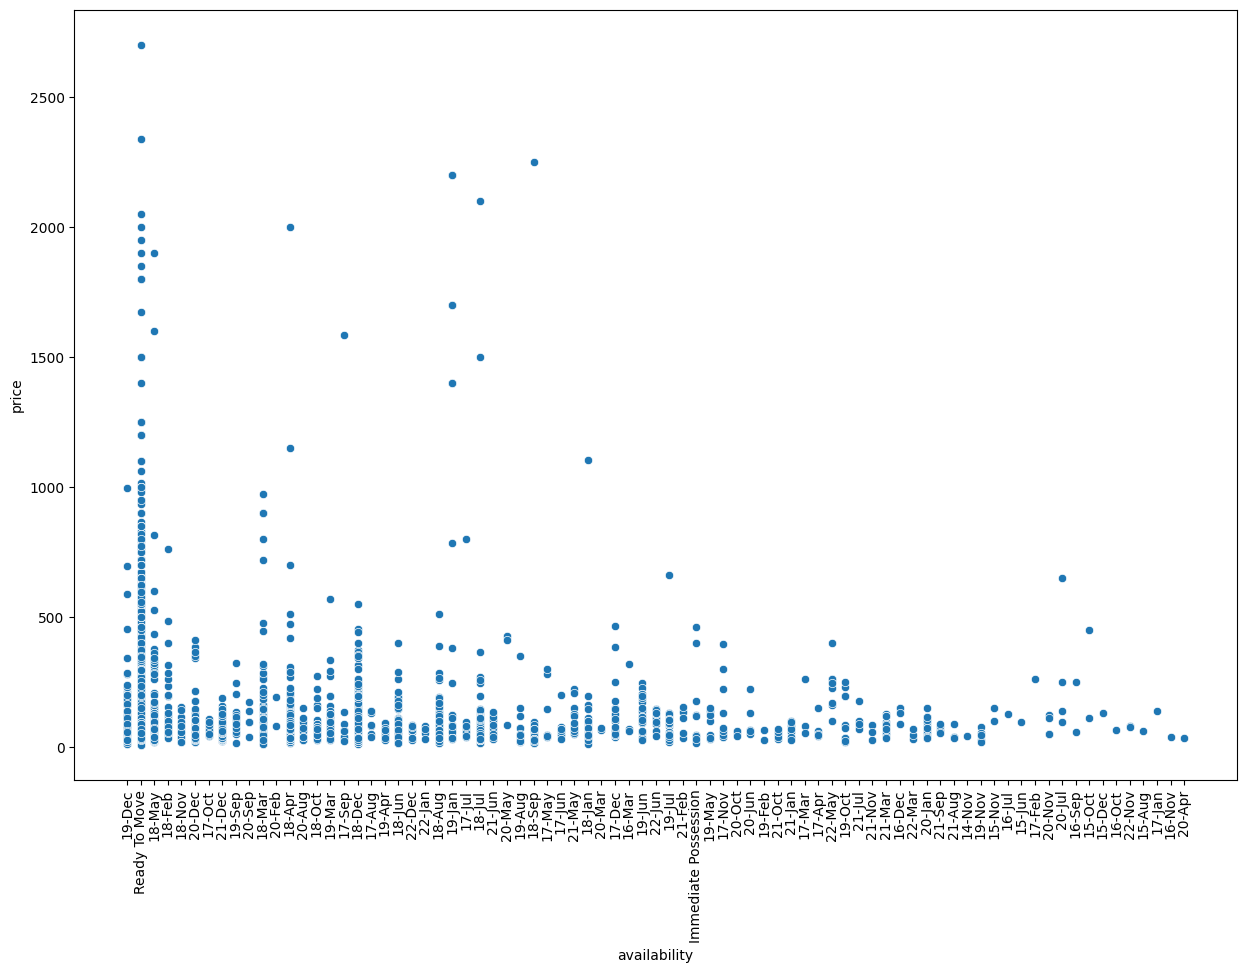

In [270]:
plt.figure(figsize=(15,10))
sns.scatterplot(x='availability', y='price', data=train_df_copy)
plt.xticks(rotation=90)
plt.show()

##### Will remove this 'availability' features 

In [278]:
train_df_copy.dropna(subset=['location'], inplace=True)

In [279]:
train_df_copy['location'].unique().tolist()

['electroniccityphaseii',
 'chikkatirupathi',
 'uttarahalli',
 'lingadheeranahalli',
 'kothanur',
 'whitefield',
 'oldairportroad',
 'rajajinagar',
 'marathahalli',
 'gandhibazar',
 '7thphasejpnagar',
 'gottigere',
 'sarjapur',
 'mysoreroad',
 'bisuvanahalli',
 'rajarajeshwarinagar',
 'ramakrishnappalayout',
 'manayatatechpark',
 'kengeri',
 'binnypete',
 'thanisandra',
 'bellandur',
 'mangammanapalya',
 'electroniccity',
 'ramagondanahalli',
 'yelahanka',
 'hebbal',
 'kasturinagar',
 'kanakpuraroad',
 'electronicscityphase1',
 'kundalahalli',
 'chikkalasandra',
 'murugeshpalya',
 'sarjapurroad',
 'ganganagar',
 'hsrlayout',
 'doddathoguru',
 'krpuram',
 'himagirimeadows',
 'adarshnagar',
 'bhoganhalli',
 'lakshminarayanapura',
 'begurroad',
 'devanahalli',
 'govindarajanagarward',
 'tharabanahalli',
 'varthur',
 'bommanahalli',
 'gunjur',
 'devarachikkanahalli',
 'doubleroad',
 'hegdenagar',
 'haralurroad',
 'hennurroad',
 'kothannur',
 'kalenaagrahara',
 'cholanayakanahalli',
 'kaval

In [280]:
train_df_copy['location'].nunique()

1157

In [281]:
loc = {
    'Electronic_City_Phase_1': ('electronic', 'phase1'),
    'Electronic_City_Phase_2': ('electronic', 'phaseii'),
    'JP_Nagar_Phase_9': ('jpnagar', 'phase9'),
    'JP_Nagar_Phase_8': ('jpnagar', 'phase8'),
    'JP_Nagar_Phase_7': ('jpnagar', 'phase7'),
    'JP_Nagar_Phase_6': ('jpnagar', 'phase6'),
    'JP_Nagar_Phase_5': ('jpnagar', 'phase5'),
    'JP_Nagar_Phase_1': ('jpnagar', 'phase1'),
    'BTM_Layout_2nd_Stage': ('btm', '2ndstage'),
    
    'Electronic_City': ('electronic',), 
    'J_P_Nagar': ('jpnagar',), 
    'BTM_Layout': ('btm',), 
    'Kanakapura': ['kanakapura','kanakpura'], 
    'Hennur': ('hennur',),
    'Thanisandra': ('thanisandra',),
    'Sarjapur': ('sarjapur',),
    'Yelahanka': ('yelahanka',),
    
    'Akshayanagar': ['akshayanagar','akshyanagar'],
    'Anekal': ('anekal',),
    'Annapurneshwari_Nagar': ('annapurneshwari',),
    'Arakere': ('arakere',),
    'Attibele': ('attibele',),
    'Bagaluru': ('bagaluru',),
    'Banashankari': ('banashankari',),
    'Banaswadi': ('banaswadi',),
    'Bannerghatta': ('bannerghatta',),
    'Basavanagudi': ('basavanagudi',),
    'Basaveswarnagar': ('basaveswarnagar',),
    'Battarahalli': ('battarahalli',),
    'Begur': ('begur',),
    'Bellandur': ('bellandur',),
    'Bidadi': ('bidadi',),
    'bidrahalli': ('bidrahalli',),
    'Bilekahalli': ('bilekahalli',),
    'Bommanahalli': ('bommanahalli','bommenahalli'),
    'Bommasandra': ('bommasandra',),
    'Brookefield': ('brookefield',),
    'Budigere_Cross': ('budigerecross',),
    'byatarayanapura': ('byatarayanapura',),
    'Carmelaram': ('carmelaram',),
    'Chamrajpet': ('chamrajpet',),
    'Chandapura': ('chandapura',),
    'Chikkalasandra': ('chikkalasandra',),
    'Cooke_Town': ('cooketown',),
    'CV_Raman_Nagar': ('cvramannagar',),
    'Dasarahalli': ('dasarahalli',),
    'Devanahalli': ('devanahalli',),
    'Doddakannelli': ('doddakannelli',),
    'Doddanekundi': ('kundi',),
    'Doddathoguru': ('doddathoguru',),
    'Domlur': ('domlur',),
    'Ejipura': ('ejipura',),
    'Frazer_Town': ('frazertown',),
    'Gottigere': ('gottigere',),
    'Gunjur': ('gunjur',),
    'Harlur': ('harlur','haralur'),
    'HBR_Layout': ('hbrlayout',),
    'Hebbal': ('hebbal',),
    'Hoodi': ('hoodi',),
    'Horamavu': ['horamavu','hormavu'],
    'Hosa_Road': ('hosaroad',),
    'Hosakerehalli': ('hosakerehalli',),
    'Hoskote': ('hoskote',),
    'HSR_Layout': ('hsrlayout',),
    'Hulimavu': ('hulimavu',),
    'Indiranagar': ('indiranagar',),
    'ITPL': ('itpl',),
    'Jakkur': ('jakkur',),
    'Jalahalli': ('jalahalli',),
    'Jayanagar': ('jayanagar',),
    'Jigani': ('jigani',),
    'Jogupalya': ('jogupalya',),
    'Kadugodi': ('kadugodi','epipzone'),
    'Kaggadasapura': ('kaggadasapura',),
    'Kalkere': ('kalkere',),
    'Kalyan_Nagar': ('kalyannagar',),
    'Kammanahalli': ('kammanahalli',),
    'Kannamangala': ('kannamangala',),
    'Kartik_Nagar': ('kartiknagar',),
    'Kasavanahalli': ('kasavanahalli',),
    'Kasturi_Nagar': ('kasturinagar',),
    'K_C_Krishna_Reddy_Layout': ('krishnareddylayout',),
    'Kengeri': ('kengeri',),
    'Kithaganur_Colony': ('kithaganurcolony',),
    'Kogilu': ('kogilu',),
    'Konanakunte': ('konanakunte',),
    'Koramangala': ('koramangala',),
    'Kothanur': ['kothanur','kothannur'],
    'KPC_Layout': ('kpclayout',),
    'Krishnarajapura': ('krishnarajapura',),
    'Kudlu': ('kudlu',),
    'Kumbalgodu': ('kumbalgodu',),
    'Kumaraswamy_Layout': ('kumaraswamylayout',),
    'Mahadevapura': ['mahadevapura','mahadevpura'],
    'Malleswaram': ('malleswaram',),
    'Margondanahalli': ('margondanahalli',),
    'Marathahalli': ('marathahalli',),
    'Marsur': ('marsur',),
    'Medahalli': ('medahalli',),
    'Munnekollal': ('munnekollal',),
    'Murugeshpalya': ('murugeshpalya',),
    'Nagavara': ('nagavara',),
    'Nagarbhavi': ('nagarbhavi',),
    'Nayandahalli': ('nayandahalli',),
    'Nelamangala': ('nelamangala',),
    'New_Thippasandra': ('thippasandra',),
    'NRI_Layout': ('nrilayout',),
    'Panathur': ('panathur',),
    'Rajajinagar': ('rajajinagar',),
    'Ramagondanahalli': ('ramagondanahalli',),
    'Ramamurthy_Nagar': ('ramamurthynagar',),
    'Rayasandra': ('rayasandra',),
    'Richmond_Town': ('richmondtown',),
    'RR_Nagar': ['rrnagar','rajarajeshwarinagar'],
    'R_T_Nagar': ('rtnagar',),
    'Sadduguntepalya': ('sadduguntepalya',),
    'Sahakar_Nagar': ('sahakarnagar',),
    'Sanjaynagar': ('sanjaynagar',),
    'seegehalli': ('seegehalli',),
    'Singasandra': ('singasandra',),
    'Sir_M_V_Nagar': ('sirmvnagar',),
    'Subramanyapura': ('subramanyapura',),
    'Talaghattapura': ('talaghattapura',),
    'T_C_Palya' : ['tcpalya', 'tcpalaya'],
    'Ulsoor': ('ulsoor',),
    'Uttarahalli': ('uttarahalli',),
    'Uttarahalli_Hobli': ('uttarahallihobli',),
    'Varthur': ('varthur',),
    'Vasanth_Nagar': ('vasanthnagar',),
    'Vibhutipura': ('vibhutipura',),
    'Vidyaranyapura': ('vidyaranyapura',),
    'Vignana_Kendra': ('vignanakendra',),
    'Vijayanagar': ('vijayanagar',),
    'Vinayakanagar': ('vinayakanagar',),
    'Volagerekallahalli': ('volagerekallahalli',),
    'Whitefield': ('whitefield',),
    'Yelahanka_New_Town': ('yelahankanewtown',),
    'Yeshwantpur': ('yeshwantpur',),
}

In [282]:


def a(x):
    # x = x.strip()
    x = x.lower()
    x = re.sub(r'[, !. /-]', '', x)
    return x

In [283]:
train_df_copy['location'] = train_df_copy['location'].apply(a)

In [285]:
train_df_copy.location

0              electroniccityphaseii
1                    chikkatirupathi
2                        uttarahalli
3                 lingadheeranahalli
4                           kothanur
                    ...             
10651              parappanaagrahara
10652                    bhoganhalli
10653    doddanakundiindustrialarea2
10654             kachanayakanahalli
10655              horamavubanaswadi
Name: location, Length: 10655, dtype: object

In [286]:
def check_insance(x):
    if isinstance(x, list):
        return any
    elif isinstance(x, tuple):
        return all

for val in loc:
    search_terms = loc[val] 
    mask = train_df_copy['location'].apply(
        lambda x: check_insance(search_terms)(term in str(x) for term in search_terms)
    )   
    train_df_copy.loc[mask, 'location'] = val

In [287]:
train_df_copy['location'].value_counts()

location
Whitefield         439
Sarjapur           393
J_P_Nagar          350
Kanakapura         260
Electronic_City    238
                  ... 
mediagrahara         1
Sadduguntepalya      1
shirdisainagar       1
williamstown         1
rmcyard              1
Name: count, Length: 987, dtype: int64

In [288]:
train_df_copy['location'].value_counts()[train_df_copy['location'].value_counts() <= 10]

location
kodigehaali          10
badavalanagar        10
Marsur               10
vishwapriyalayout    10
micolayout           10
                     ..
mediagrahara          1
Sadduguntepalya       1
shirdisainagar        1
williamstown          1
rmcyard               1
Name: count, Length: 807, dtype: int64

In [ ]:
train_df_copy

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,0,Super built-up Area,19-Dec,Electronic_City_Phase_2,2 BHK,Coomee,1056,2.0,1.0,39.07
1,1,Plot Area,Ready To Move,chikkatirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,3,Super built-up Area,Ready To Move,lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...,...
10651,10651,Plot Area,Ready To Move,parappanaagrahara,1 Bedroom,NaN,1200,1.0,0.0,45.00
10652,10652,Super built-up Area,Ready To Move,bhoganhalli,2 BHK,Srhemay,1260,2.0,1.0,69.90
10653,10653,Super built-up Area,Ready To Move,doddanakundiindustrialarea2,2 BHK,NaN,1092,2.0,1.0,49.00
10654,10654,Super built-up Area,Ready To Move,kachanayakanahalli,2 BHK,ICoolon,827,2.0,0.0,34.00


In [ ]:
f

NameError: name 'f' is not defined

##### Here some values are having spelling issue which we will correct it.

In [ ]:
train_df_copy['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK'], dtype=object)

##### Will make 1 RK as 0 and will strip the value to remove string from the column, and none values to Mode.

In [ ]:
train_df_copy['total_sqft']

0        1056
1        2600
2        1440
3        1521
4        1200
         ... 
10651    1200
10652    1260
10653    1092
10654     827
10655    1357
Name: total_sqft, Length: 10656, dtype: object

##### 'total_sqft' column is in object. Will check if there are any non-numeric values.

In [ ]:
def check_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [ ]:
train_df_copy[~train_df_copy['total_sqft'].apply(lambda x : check_float(x))]['total_sqft'].unique()

array(['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156',
       '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740',
       '34.46Sq. Meter', '1195 - 1440', '1200 - 2400', '4125Perch',
       '1120 - 1145', '4400 - 6640', '3090 - 5002', '4400 - 6800',
       '1160 - 1195', '1000Sq. Meter', '4000 - 5249', '1115 - 1130',
       '1100Sq. Yards', '520 - 645', '1000 - 1285', '3606 - 5091',
       '650 - 665', '633 - 666', '5.31Acres', '30Acres', '1445 - 1455',
       '884 - 1116', '850 - 1093', '1440 - 1884', '716Sq. Meter',
       '547.34 - 827.31', '580 - 650', '3425 - 3435', '1804 - 2273',
       '3630 - 3800', '660 - 670', '1500Sq. Meter', '620 - 933',
       '142.61Sq. Meter', '2695 - 2940', '2000 - 5634', '1574Sq. Yards',
       '3450 - 3472', '1250 - 1305', '670 - 980', '1005.03 - 1252.49',
       '1004 - 1204', '361.33Sq. Yards', '645 - 936', '2710 - 3360',
       '2249.81 - 4112.19', '3436 - 3643', '2830 - 2882', '596 - 804',
       '1255 - 1863', '1300 - 1405', '1

##### We can see that many values are having ranges and some values are having units. We will take range values as average of the range, and unit values will be None. 

In [ ]:
train_df_copy['bath'].value_counts()

bath
2.0     5530
3.0     2608
4.0      991
1.0      639
5.0      411
6.0      216
7.0       86
8.0       48
9.0       35
10.0      11
12.0       7
16.0       2
11.0       2
27.0       1
14.0       1
40.0       1
15.0       1
13.0       1
Name: count, dtype: int64

In [ ]:
train_df_copy['balcony'].value_counts()

balcony
2.0    4069
1.0    3894
3.0    1342
0.0     847
Name: count, dtype: int64

Now we will do all above steps in function for better reusability.

In [ ]:
test_df.isna().sum()

ID                 0
area_type          0
availability       0
location           0
size               2
society         1074
total_sqft         0
bath               8
balcony          105
dtype: int64

In [ ]:
train_df.columns

Index(['ID', 'area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [ ]:
del_col = ['ID', 'availability', 'society']

In [ ]:
def get_size_value(x):
    if pd.isna(x):
        return x
    return 0 if x == '1 RK' else x.split()[0]

In [ ]:
def get_sq_ft(x):
    val = x.split(' - ')
    if len(val) == 2:
        return (val[0]+val[1])/2
    return None

In [ ]:
def reuse_func(x):
    df = x.drop(columns=del_col)

    df['size'] = df['size'].apply(get_size_value)

    df['total_sqft'] = df['total_sqft'].apply(get_sq_ft)

    df['location'] = df


SyntaxError: invalid syntax (3067002872.py, line 3)

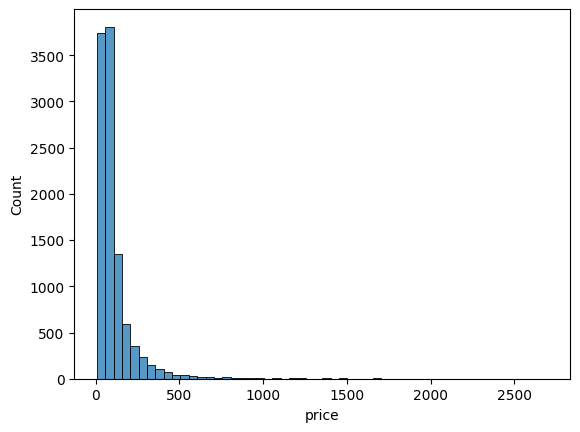

In [ ]:
sns.histplot(train_df['price'], binwidth=50)
plt.show()

In [ ]:
a = '123Sq - ft'
a = a.split(' - ')
if len(a) == 1:
    print(''.join(i for i in str(a) if i.isdigit()))
print(a)

['123Sq', 'ft']


TypeError: float() argument must be a string or a real number, not 'list'

In [ ]:
a = {
    'shashi' : 'sh',
    'shashi' : 'ha'
}

In [ ]:
isinstance(a, tuple)

False